In [ ]:

#############################################################################################
####################                   Book Worm MMM 2026             #######################

#############################################################################################

################################################################
#### Step 0: Setup environment

## install robyn
install.packages("Robyn")
library(Robyn)
packageVersion("Robyn")

## install reticulate
install.packages("reticulate")
library(reticulate)

## install python and nevergrad
py_config()
py_install("nevergrad", pip = TRUE)

## Force multi-core use when running RStudio
Sys.setenv(R_FUTURE_FORK_ENABLE = "true")
options(future.fork.enable = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] ‘3.12.1’

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



python:         /root/.cache/uv/archive-v0/ru-9G3tE682vZbSc/bin/python
libpython:      /root/.local/share/uv/python/cpython-3.12.14-linux-x86_64-gnu/lib/libpython3.12.so
pythonhome:     /root/.cache/uv/archive-v0/ru-9G3tE682vZbSc:/root/.cache/uv/archive-v0/ru-9G3tE682vZbSc
virtualenv:     /root/.cache/uv/archive-v0/ru-9G3tE682vZbSc/bin/activate_this.py
version:        3.12.14 (main, Aug 14 2026, 15:34:45) [Clang 22.1.3 ]
numpy:          /root/.cache/uv/archive-v0/ru-9G3tE682vZbSc/lib/python3.12/site-packages/numpy
numpy_version:  2.5.2

Warning message in py_install("nevergrad", pip = TRUE):
“An ephemeral virtual environment managed by 'reticulate' is currently in use.
To add more packages to your current session, call `py_require()` instead
of `py_install()`. Running:
  `py_require(c("nevergrad"))`”


In [27]:
## Libraries
library(Robyn)
library(reticulate)

################################################################
#### Step 1: Load data

## Load dataset
data <- read.csv("/content/Book_Worm_Data.csv")
head(data)

## Set Directory
robyn_directory <- "/content/Book Worm MMM Results"

################################################################
#### Step 3: Set Model specification

#### 3a-1: First, specify input variables

InputCollect <- robyn_inputs(

  dt_input = data,

  # Date & KPI
  date_var = "Date",
  dep_var = "Accounts_Subscriptions",
  dep_var_type = "conversion",

  # Add trend
  prophet_vars = c("trend"),
  prophet_country = "US",

  # Context variables
  context_vars = c(
    "Dates_School_Holidays",
    "Competitors_Promotion"
  ),

  # Paid media spends
  paid_media_spends = c(
    "Google_Display_Cost",
    "Meta_Cost",
    "Google_Generic_Paid_Search_Cost",
    "TV_Cost",
    "Influencers_Cost",
    "Google_Branded_Paid_Search_Cost",
    "YouTube_Cost"
  ),

  # Media exposure metrics
  paid_media_vars = c(
    "Google_Display_Impressions",
    "Meta_Impressions",
    "Google_Generic_Paid_Search_Impressions",
    "TV_GRP",
    "Influencers_Views",
    "Google_Branded_Paid_Search_Clicks",
    "YouTube_Impressions"
  ),

  # External controls
  organic_vars = NULL,
  factor_vars = NULL,

  # Modeling window
  window_start = "2022-01-01",
  window_end = "2024-12-28",

  # Adstock
  adstock = "weibull_cdf"
)

print(InputCollect)

#### 3a-2: Second, define and add hyperparameters

hyper_names(adstock = InputCollect$adstock, all_media = InputCollect$all_media)

plot_adstock(plot = FALSE)
plot_saturation(plot = FALSE)

hyperparameters <- list(

  # Google Display
  Google_Display_Impressions_alphas = c(0.5, 3),
  Google_Display_Impressions_gammas = c(0.3, 1),
  Google_Display_Impressions_shapes = c(0.0001, 2),
  Google_Display_Impressions_scales = c(0, 0.1),

  # Meta
  Meta_Impressions_alphas = c(0.5, 3),
  Meta_Impressions_gammas = c(0.3, 1),
  Meta_Impressions_shapes = c(0.0001, 2),
  Meta_Impressions_scales = c(0, 0.1),

  # Generic Search
  Google_Generic_Paid_Search_Impressions_alphas = c(0.5, 3),
  Google_Generic_Paid_Search_Impressions_gammas = c(0.3, 1),
  Google_Generic_Paid_Search_Impressions_shapes = c(0.0001, 2),
  Google_Generic_Paid_Search_Impressions_scales = c(0, 0.1),

  # TV
  TV_GRP_alphas = c(0.5, 3),
  TV_GRP_gammas = c(0.3, 1),
  TV_GRP_shapes = c(0.0001, 5),
  TV_GRP_scales = c(0, 0.2),

  # Influencers
  Influencers_Views_alphas = c(0.5, 3),
  Influencers_Views_gammas = c(0.3, 1),
  Influencers_Views_shapes = c(0.0001, 3),
  Influencers_Views_scales = c(0, 0.15),

  # Branded Search
  Google_Branded_Paid_Search_Clicks_alphas = c(0.5, 3),
  Google_Branded_Paid_Search_Clicks_gammas = c(0.3, 1),
  Google_Branded_Paid_Search_Clicks_shapes = c(0.0001, 1),
  Google_Branded_Paid_Search_Clicks_scales = c(0, 0.05),

  # YouTube
  YouTube_Impressions_alphas = c(0.5, 3),
  YouTube_Impressions_gammas = c(0.3, 1),
  YouTube_Impressions_shapes = c(0.0001, 3),
  YouTube_Impressions_scales = c(0, 0.15)
)

  # add hyperparameters into robyn_inputs()

InputCollect <- robyn_inputs(InputCollect = InputCollect, hyperparameters = hyperparameters)
print(InputCollect)

################################################################
#### Step 4: Initial Model Building

OutputModels <- robyn_run(
  InputCollect = InputCollect,
  # cores = parallel::detectCores() - 1,
  iterations = 1000,
  trials = 2,
  Outputs = FALSE
)

################################################################
#### Step 5: Export Results

OutputCollect <- robyn_outputs(
  InputCollect = InputCollect,
  OutputModels = OutputModels,
  pareto_fronts = 1,
  export = TRUE,
  plot_folder = robyn_directory
)

,Date,Accounts_Subscriptions,Google_Display_Impressions,Google_Display_Cost,Meta_Impressions,Meta_Cost,Google_Generic_Paid_Search_Impressions,Google_Generic_Paid_Search_Cost,TV_GRP,TV_Cost,Influencers_Views,Influencers_Cost,Google_Branded_Paid_Search_Clicks,Google_Branded_Paid_Search_Cost,YouTube_Impressions,YouTube_Cost,Dates_School_Holidays,Competitors_Promotion,Promotion
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>
1,2022-01-01,4182.0,49,5.2934997,3501804,11637.193,152181,5322.200,0.0000,0.000,0,0,4049,3580.52,1951,5572.056,0,14,14
2,2022-01-08,5167.5,1061,93.7447310,2896152,9171.139,167010,8332.182,0.0000,0.000,698,2094,4497,5089.80,1914,5466.384,6,14,14
3,2022-01-15,6229.0,20,1.5536994,2214403,8847.930,179189,11375.953,274.2857,6308.571,353,1059,5787,6805.89,4801,13711.656,7,14,14
4,2022-01-22,7801.5,3088,240.3010701,2567241,8113.658,209859,10568.902,1920.0000,44160.000,58,174,7032,8085.96,5925,16921.800,7,14,14
5,2022-01-29,9505.0,11,1.1751350,3721507,11027.987,214967,10806.540,1920.0000,44160.000,88,264,6943,7761.05,13061,37302.216,7,14,14
6,2022-02-05,9369.5,3,0.1256955,2962649,9453.031,195181,9430.725,1920.0000,44160.000,24,72,6750,7357.51,11350,32415.600,7,14,14


Warning message in check_prophet(dt_holidays, prophet_country, prophet_vars, prophet_signs, :
“Input 'prophet_country' is defined as US but 'holiday' is not setup within 'prophet_vars' parameter”


Total Observations: 157 (weeks)
Input Table Columns (19):
  Date: Date
  Dependent: Accounts_Subscriptions [conversion]
  Paid Media: Google_Display_Impressions, Meta_Impressions, Google_Generic_Paid_Search_Impressions, TV_GRP, Influencers_Views, Google_Branded_Paid_Search_Clicks, YouTube_Impressions
  Paid Media Spend: Google_Display_Cost, Meta_Cost, Google_Generic_Paid_Search_Cost, TV_Cost, Influencers_Cost, Google_Branded_Paid_Search_Cost, YouTube_Cost
  Context: Dates_School_Holidays, Competitors_Promotion
  Organic: 
  Prophet (Auto-generated): trend on US
  Unused variables: Promotion

Date Range: 2022-01-01:2024-12-28
Model Window: 2022-01-01:2024-12-28 (157 weeks)
With Calibration: FALSE
Custom parameters: None

Adstock: weibull_cdf
Hyper-parameters: Not set yet


[1] "Google_Branded_Paid_Search_Clicks_alphas"     
 [2] "Google_Branded_Paid_Search_Clicks_gammas"     
 [3] "Google_Branded_Paid_Search_Clicks_scales"     
 [4] "Google_Branded_Paid_Search_Clicks_shapes"     
 [5] "Google_Display_Impressions_alphas"            
 [6] "Google_Display_Impressions_gammas"            
 [7] "Google_Display_Impressions_scales"            
 [8] "Google_Display_Impressions_shapes"            
 [9] "Google_Generic_Paid_Search_Impressions_alphas"
[10] "Google_Generic_Paid_Search_Impressions_gammas"
[11] "Google_Generic_Paid_Search_Impressions_scales"
[12] "Google_Generic_Paid_Search_Impressions_shapes"
[13] "Influencers_Views_alphas"                     
[14] "Influencers_Views_gammas"                     
[15] "Influencers_Views_scales"                     
[16] "Influencers_Views_shapes"                     
[17] "Meta_Impressions_alphas"                      
[18] "Meta_Impressions_gammas"                      
[19] "Meta_Impressions_scales"                      
[20] "Meta_Impressions_shapes"                      
[21] "TV_GRP_alphas"                                
[22] "TV_GRP_gammas"                                
[23] "TV_GRP_scales"                                
[24] "TV_GRP_shapes"                                
[25] "YouTube_Impressions_alphas"                   
[26] "YouTube_Impressions_gammas"                   
[27] "YouTube_Impressions_scales"                   
[28] "YouTube_Impressions_shapes"

Warning message in check_hyperparameters(InputCollect$hyperparameters, InputCollect$adstock, :
“Automatically added missing hyperparameter range: 'train_size' = c(0.5, 0.8)”
>> Running feature engineering...

Warning message in check_prophet(dt_holidays, prophet_country, prophet_vars, prophet_signs, :
“Input 'prophet_country' is defined as US but 'holiday' is not setup within 'prophet_vars' parameter”
NOTE: potential improvement on splitting channels for better spend exposure fitting. Threshold (min.adj.R2) = 0.8 
  Check: InputCollect$ExposureCollect$plot_spend_exposure outputs
  Weak relationship for: 'Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions', 'TV_GRP', 'Google_Branded_Paid_Search_Clicks' and their spend



...

>> Pareto-Front: 1 [24 models]



 00:00:06 [=========================================] 100% | 24                      


Creating directory for outputs: /content/Book Worm MMM Results/Robyn_202608311651_init/

>>> Calculating clusters for model selection using Pareto fronts...

>> Auto selected k = 3 (clusters) based on minimum WSS variance of 6%

>>> Collecting 24 pareto-optimum results into: /content/Book Worm MMM Results/Robyn_202608311651_init/

>> Exporting general plots into directory...

>> Exporting pareto results as CSVs into directory...

>>> Exporting pareto one-pagers into directory...

>> Generating only cluster results one-pagers (3)...

>> Plotting 3 selected models on 1 cores...



  |======================================================================| 100%


>> Exported models as /content/Book Worm MMM Results/Robyn_202608311651_init/RobynModel-models.json



In [31]:
################################################################
#### Step6: View Model IDs

## View Model IDs
OutputCollect$allSolutions


[1] "1_853_1" "1_913_1" "1_918_1" "1_919_1" "1_973_1" "1_979_1" "2_770_1"
 [8] "2_789_1" "2_830_1" "2_860_1" "2_869_1" "2_897_1" "2_919_1" "2_920_1"
[15] "2_937_1" "2_951_1" "2_954_1" "2_959_1" "2_967_1" "2_979_1" "2_980_1"
[22] "2_982_1" "2_989_1" "2_997_1"

In [32]:
################################################################
#### Step7: Select Best Model

OutputCollect <- robyn_outputs(
  InputCollect = InputCollect,
  OutputModels = OutputModels,
  select_model = "2_980_1",
  export = TRUE,
  plot_folder = robyn_directory
)

>>> Running Pareto calculations for 2000 models on auto fronts...

>> Automatically selected 5 Pareto-fronts to contain at least 100 pareto-optimal models (101)

>>> Calculating response curves for all models' media variables (707)...



  |======================================================================| 100%


>> Pareto-Front: 1 [24 models]



 00:00:06 [=========================================] 100% | 24                      


>> Pareto-Front: 2 [13 models]



...

>> Pareto-Front: 4 [20 models]



 00:00:05 [=========================================] 100% | 20                      


>> Pareto-Front: 5 [28 models]



 00:00:08 [=========================================] 100% | 28                      


Creating directory for outputs: /content/Book Worm MMM Results/Robyn_202608311703_init/

>>> Calculating clusters for model selection using Pareto fronts...

Warning message in robyn_clusters(OutputCollect, dep_var_type = InputCollect$dep_var_type, :
“Too few clusters: 2. Setting to 3”
>> Auto selected k = 3 (clusters) based on minimum WSS variance of 6%

>>> Collecting 101 pareto-optimum results into: /content/Book Worm MMM Results/Robyn_202608311703_init/

>> Exporting general plots into directory...

>> Exporting pareto results as CSVs into directory...

>>> Exporting pareto one-pagers into directory...

Exporting charts as: /content/Book Worm MMM Results/Robyn_202608311703_init/2_980_1.png

>> Exported models as /content/Book Worm MMM Results/Robyn_202608311703_init/RobynModel-models.json



In [34]:
################################################################
#### Step8: Budget Allocation

AllocatorCollect <- robyn_allocator(
  InputCollect = InputCollect,
  OutputCollect = OutputCollect,
  select_model = "2_980_1",
  scenario = "max_response",
  channel_constr_low = 0.8,
  channel_constr_up = 1.2,
  export = TRUE
)


>>> Running budget allocator for model ID 2_980_1 ...

Date Window: 2022-01-01:2024-12-28 (157 weeks)

Exporting to: /content/Book Worm MMM Results/Robyn_202608311703_init/2_980_1_reallocated_best_cpa.png



Model ID: 2_980_1
Scenario: max_response
Use case: all_historical_vec + historical_budget
Window: 2022-01-01:2024-12-28 (157 weeks)

Dep. Variable Type: conversion
Media Skipped: 
Relative Spend Increase: -0% (0)
Total Response Increase (Optimized): 3.43%

Allocation Summary:
  
- Google_Branded_Paid_Search_Clicks:
  Optimizable bound: [-20%, 20%],
  Initial spend share: 18.2% -> Optimized bounded: 14.8%
  Initial response share: 20% -> Optimized bounded: 17%
  Initial abs. mean spend: 11.35K -> Optimized: 9.247K [Delta = -19%]
  
- Google_Display_Impressions:
  Optimizable bound: [-20%, 20%],
  Initial spend share: 2.69% -> Optimized bounded: 2.15%
  Initial response share: 0.0974% -> Optimized bounded: 0.0633%
  Initial abs. mean spend: 1.678K -> Optimized: 1.343K [Delta = -20%]
  
- Google_Generic_Paid_Search_Impressions:
  Optimizable bound: [-20%, 20%],
  Initial spend share: 21.1% -> Optimized bounded: 25.3%
  Initial response share: 21.3% -> Optimized bounded: 25.3%
  Initial ab

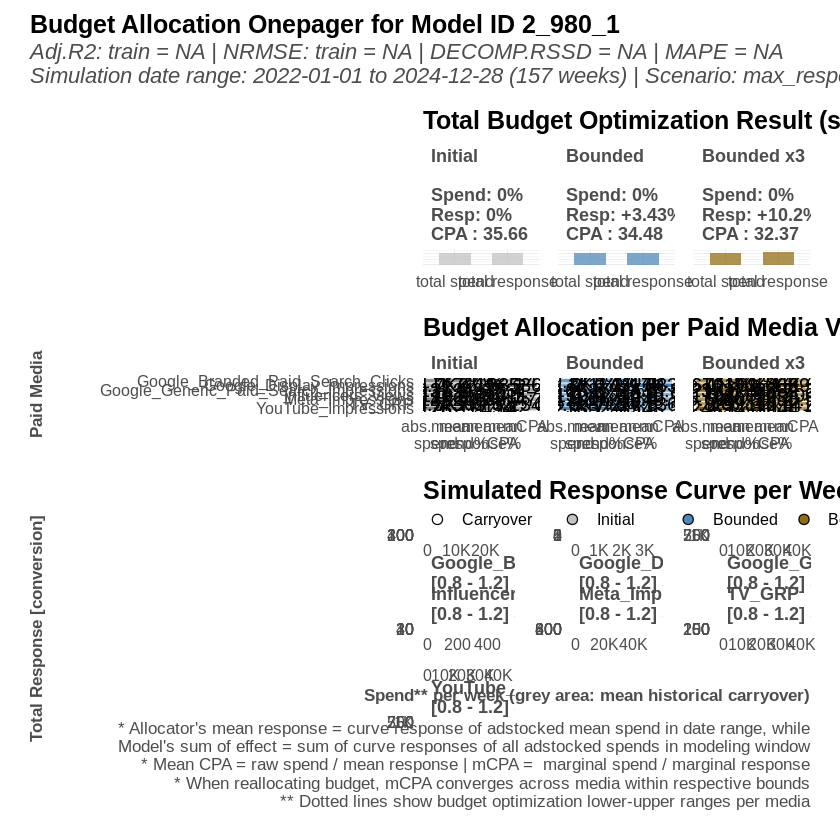

In [35]:
################################################################
#### Step9: View Allocation Results

print(AllocatorCollect)

plot(AllocatorCollect)

In [37]:
zip(
  zipfile = "/content/Book_Worm_MMM_Results.zip",
  files = "/content/Book Worm MMM Results"
)